In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"

In [2]:
# Radar Chart with 5 Metrics:
# Scoring = (PTS / MIN) * 36
# Efficiency = PTS / (2 * (FGA + 0.44 * FTA))
# Playmaking = ((AST - TOV) / MIN) * 36
# Defense = ((STL + BLK - (PF * 0.5)) / MIN) * 36
# Control = ((DREB + (OREB * 1.5)) / MIN) * 36
# GameScore = PTS + 0.4 * FGM – 0.7 *FGA – 0.4 * (FTA – FTM) + 0.7 * OREB + 0.3 * DREB + STL + 0.7 * AST + 0.7 * BLK - 0.4 * PF - TO

In [3]:
career_path = DATA_DIR / "career_totals_targets.csv"
career_total_df = pd.read_csv(career_path)
split_path = DATA_DIR / "player_train_test_split.csv"
train_test_split_df = pd.read_csv(split_path)

In [4]:
season_col = 'SEASON_ID'
team_col = 'TEAM_ABBREVIATION'

# Clean Career Data to Prevent Double-Counting ---
if team_col in career_total_df.columns:
    initial_len = len(career_total_df)
    
    # Create a temporary boolean column that is True ONLY if the team is 'TOT'
    career_total_df['IS_TOT'] = career_total_df[team_col] == 'TOT'
    
    # Sort so that True ('TOT') comes before False for any given Player/Season combination
    career_total_df = career_total_df.sort_values(
        by=['PLAYER_ID', season_col, 'IS_TOT'], 
        ascending=[True, True, False]
    )
    
    # Drop duplicates, keeping the first row (which is guaranteed to be 'TOT' if it exists)
    career_total_df = career_total_df.drop_duplicates(subset=['PLAYER_ID', season_col], keep='first')
    
    # Clean up the temporary column
    career_total_df = career_total_df.drop(columns=['IS_TOT'])
    
    print(f"Cleaned dataset: Dropped {initial_len - len(career_total_df)} partial team rows.")

Cleaned dataset: Dropped 1903 partial team rows.


In [5]:
def get_target_seasons(forecast_str):
    """Parses '2003-2006' into ['2003-04', '2004-05', '2005-06']"""
    try:
        start_yr, end_yr = map(int, forecast_str.split('-'))
        return [f"{yr}-{str(yr+1)[-2:].zfill(2)}" for yr in range(start_yr, end_yr)]
    except:
        return []

# Identify the core counting stats needed for the 5 metrics
stats_cols = ['MIN', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']

# Aggregating 3-year target stats from career totals
aggregated_rows = []

for index, row in train_test_split_df.iterrows():
    player_id = row['PLAYER_ID']
    target_seasons = get_target_seasons(row['FORECAST_SEASON'])
    
    # Filter for this player's specific target seasons
    player_seasons = career_total_df[
        (career_total_df['PLAYER_ID'] == player_id) & 
        (career_total_df[season_col].isin(target_seasons))
    ]
        
    # Sum the stats for those 3 years
    if not player_seasons.empty:
        summed_stats = player_seasons[stats_cols].sum().to_dict()
    else:
        summed_stats = {col: 0 for col in stats_cols}
        
    # Append the calculated stats directly (no need to store PLAYER_ID for merging)
    aggregated_rows.append(summed_stats)

# Convert to DataFrame using the EXACT index of the original split dataframe
agg_df = pd.DataFrame(aggregated_rows, index=train_test_split_df.index)

# Join them horizontally by index to completely avoid duplicate row creation
train_test_split_df = train_test_split_df.join(agg_df)

In [ ]:
# Calculating Raw Metrics
min_safe = np.where(train_test_split_df['MIN'] > 0, train_test_split_df['MIN'], np.nan)
ts_denom = 2 * (train_test_split_df['FGA'] + 0.44 * train_test_split_df['FTA'])
ts_safe = np.where(ts_denom > 0, ts_denom, np.nan)

train_test_split_df['Scoring_Metric_Raw'] = (train_test_split_df['PTS'] / min_safe) * 36
train_test_split_df['Efficiency_Metric_Raw'] = train_test_split_df['PTS'] / ts_safe
train_test_split_df['Playmaking_Metric_Raw'] = ((train_test_split_df['AST'] - train_test_split_df['TOV']) / min_safe) * 36
train_test_split_df['Defense_Metric_Raw'] = ((train_test_split_df['STL'] + train_test_split_df['BLK'] - (train_test_split_df['PF'] * 0.5)) / min_safe) * 36
train_test_split_df['Control_Metric_Raw'] = ((train_test_split_df['DREB'] + (train_test_split_df['OREB'] * 1.5)) / min_safe) * 36
train_test_split_df['Game_Score'] = (
    train_test_split_df['PTS'] + 
    0.4 * train_test_split_df['FGM'] - 
    0.7 * train_test_split_df['FGA'] - 
    0.4 * (train_test_split_df['FTA'] - train_test_split_df['FTM']) + 
    0.7 * train_test_split_df['OREB'] + 
    0.3 * train_test_split_df['DREB'] + 
    train_test_split_df['STL'] + 
    0.7 * train_test_split_df['AST'] + 
    0.7 * train_test_split_df['BLK'] - 
    0.4 * train_test_split_df['PF'] - 
    train_test_split_df['TOV']
)

metrics = ['Scoring', 'Efficiency', 'Playmaking', 'Defense', 'Control']
for m in metrics:
    train_test_split_df[f"{m}_Metric_Raw"] = train_test_split_df[f"{m}_Metric_Raw"].fillna(0)

# Scale 0-100 Based Strictly on Train Set
train_mask = train_test_split_df['SPLIT'].str.lower() == 'train'
train_df = train_test_split_df[train_mask]

scaler_bounds = {}

# Fit bounds (1st to 99th percentile) on Train only
for m in metrics:
    raw_col = f"{m}_Metric_Raw"
    p_min = float(train_df[raw_col].quantile(0.01))
    p_max = float(train_df[raw_col].quantile(0.99))
    scaler_bounds[m] = {'min': p_min, 'max': p_max}

# Apply bounds to both Train and Test
for m in metrics:
    raw_col = f"{m}_Metric_Raw"
    score_col = f"{m}_Metric_Score"
    
    p_min = scaler_bounds[m]['min']
    p_max = scaler_bounds[m]['max']
    
    if p_max == p_min:
        train_test_split_df[score_col] = 0
    else:
        train_test_split_df[score_col] = ((train_test_split_df[raw_col] - p_min) / (p_max - p_min)) * 100
        train_test_split_df[score_col] = train_test_split_df[score_col].clip(lower=0, upper=100)

save_path = DATA_DIR / "player_train_test_split_with_score.csv"
train_test_split_df.to_csv(save_path, index=False)

print(scaler_bounds)

{'Scoring': {'min': 5.948488745980708, 'max': 29.056755085602205}, 'Efficiency': {'min': 0.4515526967481551, 'max': 0.6642854808770307}, 'Playmaking': {'min': -1.374456565656566, 'max': 6.62258161115656}, 'Defense': {'min': -1.166874454905626, 'max': 1.97385633673476}, 'Control': {'min': 2.6408139799287644, 'max': 17.44185925680722}}


In [7]:
# Each year's Real Score
# 1. Calculate Safe Denominators for the new dataframe
min_safe = np.where(career_total_df['MIN'] > 0, career_total_df['MIN'], np.nan)
ts_denom = 2 * (career_total_df['FGA'] + 0.44 * career_total_df['FTA'])
ts_safe = np.where(ts_denom > 0, ts_denom, np.nan)

# 2. Calculate Raw Metrics
career_total_df['Scoring_Metric_Raw'] = (career_total_df['PTS'] / min_safe) * 36
career_total_df['Efficiency_Metric_Raw'] = career_total_df['PTS'] / ts_safe
career_total_df['Playmaking_Metric_Raw'] = ((career_total_df['AST'] - career_total_df['TOV']) / min_safe) * 36
career_total_df['Defense_Metric_Raw'] = ((career_total_df['STL'] + career_total_df['BLK'] - (career_total_df['PF'] * 0.5)) / min_safe) * 36
career_total_df['Control_Metric_Raw'] = ((career_total_df['DREB'] + (career_total_df['OREB'] * 1.5)) / min_safe) * 36

metrics = ['Scoring', 'Efficiency', 'Playmaking', 'Defense', 'Control']
score_columns = []

# 3. Apply the existing scaler_bounds to calculate scores
for m in metrics:
    raw_col = f"{m}_Metric_Raw"
    score_col = f"{m}_Metric_Score"
    score_columns.append(score_col)
    
    # Extract bounds mapped from your training set
    p_min = scaler_bounds[m]['min']
    p_max = scaler_bounds[m]['max']
    
    if p_max == p_min:
        career_total_df[score_col] = 0
    else:
        # Scale to 0-100 and clip
        career_total_df[score_col] = ((career_total_df[raw_col] - p_min) / (p_max - p_min)) * 100
        career_total_df[score_col] = career_total_df[score_col].clip(lower=0, upper=100)

# 4. Filter down to the requested columns
cols_to_keep = ['PLAYER_ID', 'PLAYER_NAME', 'SEASON_ID'] + score_columns
career_scores_df = career_total_df[cols_to_keep].copy()

career_scores_df.to_csv(DATA_DIR / "player_per_season_performance_score.csv", index=False)

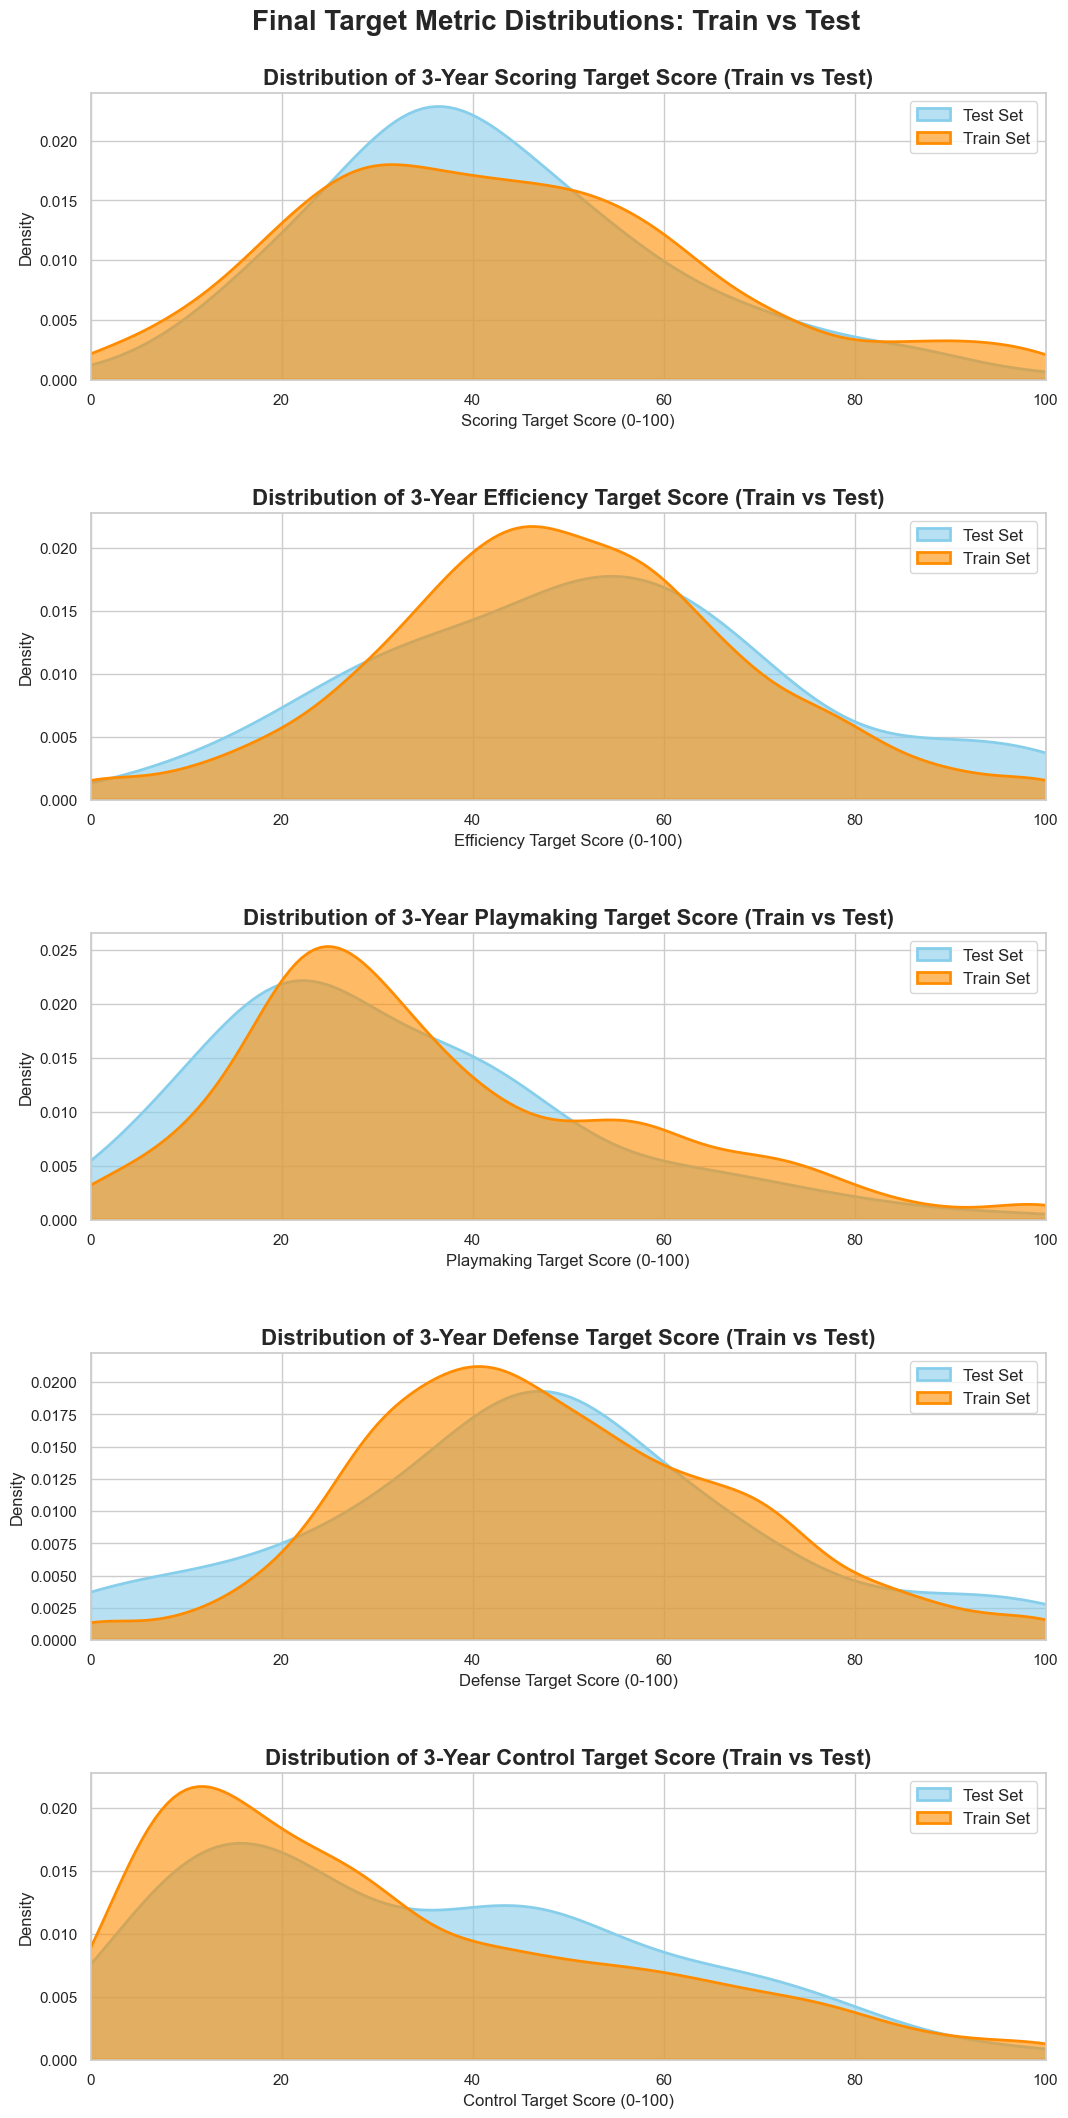

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 22))
fig.tight_layout(pad=6.0)

for i, m in enumerate(metrics):
    score_col = f"{m}_Metric_Score"
    ax = axes[i]
    
    # Plot Test Set (Blue)
    sns.kdeplot(
        data=train_test_split_df[train_test_split_df['SPLIT'].str.lower() == 'test'], 
        x=score_col, 
        fill=True, 
        color="skyblue", 
        label="Test Set", 
        alpha=0.6,
        linewidth=2,
        ax=ax
    )
    
    # Plot Train Set (Orange)
    sns.kdeplot(
        data=train_test_split_df[train_test_split_df['SPLIT'].str.lower() == 'train'], 
        x=score_col, 
        fill=True, 
        color="darkorange", 
        label="Train Set", 
        alpha=0.6,
        linewidth=2,
        ax=ax
    )
    
    ax.set_title(f"Distribution of 3-Year {m} Target Score (Train vs Test)", fontsize=16, fontweight='bold')
    ax.set_xlabel(f"{m} Target Score (0-100)", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_xlim(0, 100)
    ax.legend(fontsize=12, loc='upper right')

fig.suptitle("Final Target Metric Distributions: Train vs Test", fontsize=20, fontweight='bold', y=0.99)
plt.show()

In [ ]:
# According to https://basketballmonster.com/PlayerRankings.aspx
# rank 1: Nikola Jokić
# rank 50: Jalen Brunson
# rank 184: Gary Trent Jr.
target_players = ['Nikola Jokić', 'Jalen Brunson', 'Gary Trent Jr.']
df_radar = career_total_df[
    (career_total_df['SEASON_ID'] == '2024-25') &
    (career_total_df['PLAYER_NAME'].isin(target_players))
].copy()

# Calculate the 5 Metrics
min_safe = np.where(df_radar['MIN'] > 0, df_radar['MIN'], np.nan)
ts_denom = 2 * (df_radar['FGA'] + 0.44 * df_radar['FTA'])
ts_safe = np.where(ts_denom > 0, ts_denom, np.nan)

df_radar['Scoring_Metric_Raw'] = (df_radar['PTS'] / min_safe) * 36
df_radar['Efficiency_Metric_Raw'] = df_radar['PTS'] / ts_safe
df_radar['Playmaking_Metric_Raw'] = ((df_radar['AST'] - df_radar['TOV']) / min_safe) * 36
df_radar['Defense_Metric_Raw'] = ((df_radar['STL'] + df_radar['BLK'] - (df_radar['PF'] * 0.5)) / min_safe) * 36
df_radar['Control_Metric_Raw'] = ((df_radar['DREB'] + (df_radar['OREB'] * 1.5)) / min_safe) * 36

metrics = ['Scoring', 'Efficiency', 'Playmaking', 'Defense', 'Control']
for m in metrics:
    df_radar[f"{m}_Metric_Raw"] = df_radar[f"{m}_Metric_Raw"].fillna(0)

for m in metrics:
    raw_col = f"{m}_Metric_Raw"
    score_col = f"{m}_Metric_Score"
    
    p_min = scaler_bounds[m]['min']
    p_max = scaler_bounds[m]['max']
    
    if p_max == p_min:
        df_radar[score_col] = 0
    else:
        df_radar[score_col] = ((df_radar[raw_col] - p_min) / (p_max - p_min)) * 100
        df_radar[score_col] = df_radar[score_col].clip(lower=0, upper=100)

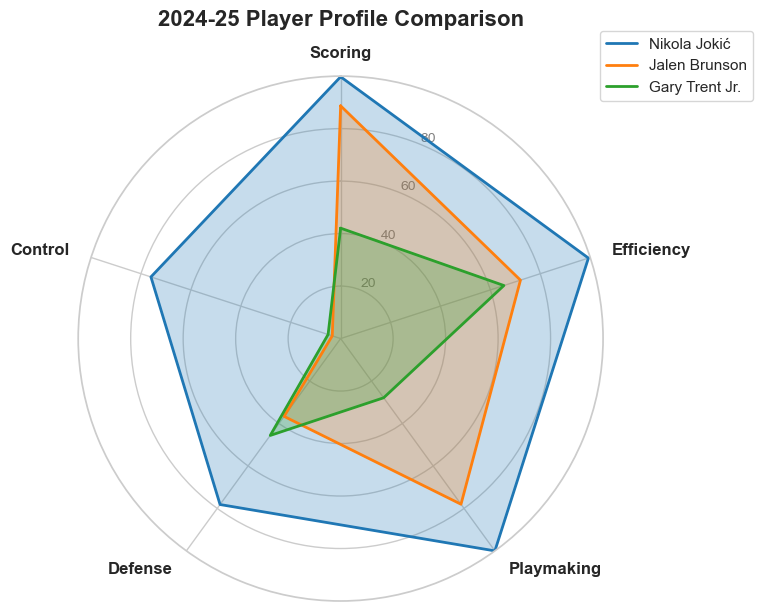

In [25]:
# Generate the Radar Chart
num_vars = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Complete the loop for plotting

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Rotate so the first metric (Scoring) is at the top
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Draw the axis lines and labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')

# Set y-axis bounds (0 to 100) and gridlines
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(['20', '40', '60', '80'], color="grey", size=10)

# Define some distinct colors for the players
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

# Plot each player
for i, (idx, row) in enumerate(df_radar.iterrows()):
    player_name = row['PLAYER_NAME']
    
    # Extract the 5 metric scores
    values = [row[f"{m}_Metric_Score"] for m in metrics]
    values += values[:1] # Complete the loop to close the polygon
    
    color = colors[i % len(colors)]
    
    # Plot line and fill area
    ax.plot(angles, values, color=color, linewidth=2, label=player_name)
    ax.fill(angles, values, color=color, alpha=0.25)

# Add title and legend
plt.title('2024-25 Player Profile Comparison', size=16, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

# Adjust label alignments to prevent overlap with the graph
for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
    if angle in (0, np.pi):
        label.set_horizontalalignment('center')
    elif 0 < angle < np.pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')

plt.tight_layout()
plt.show()